# Protocol 1 — CPP signature: physicochemical differences between two protein sets

**The key AAanalysis protocol.** Given two groups of protein sequences (e.g. substrates vs. non-substrates, binders vs. non-binders, toxic vs. non-toxic), *Comparative Physicochemical Profiling* (CPP) identifies the set of position-resolved physicochemical features that most distinctly separate them.

This protocol is part of the [Protocols catalog](https://github.com/breimanntools/aaanalysis/issues/35). It follows the standard pipeline-chained structure: *When to use it -> Input -> Run -> Output -> How to interpret -> Common mistakes -> Next step.*

## When to use it

Use this protocol when you have **two labelled sets of sequences** and want to answer: *"Which physicochemical patterns distinguish my groups, and where in the sequence do they act?"* - without first committing to a black-box model.

Typical questions: substrate vs. non-substrate, cleaved vs. not cleaved, aggregation-prone vs. soluble, toxic vs. non-toxic.

## Input

A `df_seq` with one row per protein and a binary `label` column (test class vs. reference class). Here we use the bundled `DOM_GSEC` gamma-secretase dataset. For a residue/window task you would construct windows first (see the *Sampling* protocol); for embeddings/structure see the *Engineer features* protocol (`CPP.run_num`).

In [1]:
import aaanalysis as aa

aa.options["verbose"] = False
aa.options["random_state"] = 42

# Two labelled sets of sequences (label: 1 = substrate/test, 0 = reference)
df_seq = aa.load_dataset(name="DOM_GSEC")
labels = df_seq["label"].to_list()
df_seq.head()

,entry,sequence,label,tmd_start,tmd_stop,jmd_n,tmd,jmd_c
0,P05067,MLPGLALLLLAAWTARALEVPTDGNAGLLAEPQIAMFCGRLNMHMN...,1,701,723,FAEDVGSNKG,AIIGLMVGGVVIATVIVITLVML,KKKQYTSIHH
1,P14925,MAGRARSGLLLLLLGLLALQSSCLAFRSPLSVFKRFKETTRSFSNE...,1,868,890,KLSTEPGSGV,SVVLITTLLVIPVLVLLAIVMFI,RWKKSRAFGD
2,P70180,MRSLLLFTFSACVLLARVLLAGGASSGAGDTRPGSRRRAREALAAQ...,1,477,499,PCKSSGGLEE,SAVTGIVVGALLGAGLLMAFYFF,RKKYRITIER
3,Q03157,MGPTSPAARGQGRRWRPPPLPLLLPLSLLLLRAQLAVGNLAVGSPS...,1,585,607,APSGTGVSRE,ALSGLLIMGAGGGSLIVLSLLLL,RKKKPYGTIS
4,Q06481,MAATGTAAAAATGRLLLLLLVGLTAPALALAGYIEALAANAGTGFA...,1,694,716,LREDFSLSSS,ALIGLLVIAVAIATVIVISLVML,RKRQYGTISH


## Run

The **real** minimal path (not a one-liner): build sequence *parts* with `SequenceFeature`, construct `CPP` on those parts and call `run` with the labels, then rank the resulting signature by importance with a `TreeModel`. `CPP()` takes `df_parts` - it does **not** take `df_seq`/`labels` directly.

In [2]:
# 1) Split each sequence into parts (TMD / JMD-N / JMD-C by default)
sf = aa.SequenceFeature()
df_parts = sf.get_df_parts(df_seq=df_seq)

# 2) Run CPP on the parts to obtain the most discriminant features
cpp = aa.CPP(df_parts=df_parts)
df_feat = cpp.run(labels=labels, n_filter=50)
df_feat.head(8)

,feature,category,subcategory,scale_name,scale_description,abs_auc,abs_mean_dif,mean_dif,std_test,std_ref,p_val_mann_whitney,p_val_fdr_bh,positions
0,"TMD_C_JMD_C-Segment(2,3)-QIAN880106",Conformation,α-helix,α-helix (middle),Weights for alpha-helix at the window position...,0.387,0.118,0.118,0.068,0.080,6.657990e-14,1.931283e-09,"27,28,29,30,31,32,33"
1,"TMD_C_JMD_C-Pattern(C,10,14)-CRAJ730103",Conformation,β-turn,β-turn,"Normalized frequency of turn (Crawford et al.,...",0.377,0.285,-0.285,0.164,0.177,2.999993e-13,2.900693e-09,"27,31"
2,"TMD_C_JMD_C-Segment(6,9)-FAUJ880104",Shape,Side chain length,Steric parameter,STERIMOL length of the side chain (Fauchere et...,0.367,0.263,0.263,0.161,0.168,1.128359e-12,8.182581e-09,"32,33"
3,"TMD_C_JMD_C-Segment(6,9)-ONEK900101",Others,Unclassified (Others),ΔG values in peptides,Delta G values for the peptides extrapolated t...,0.366,0.111,0.111,0.070,0.114,1.322730e-12,7.673686e-09,"32,33"
4,"TMD_C_JMD_C-Pattern(N,4,8,12,15)-QIAN880107",Conformation,α-helix,α-helix (middle),Weights for alpha-helix at the window position...,0.363,0.162,0.162,0.091,0.118,2.051752e-12,6.612798e-09,"24,28,32,35"
5,"TMD_C_JMD_C-Segment(3,4)-HUTJ700103",Energy,Entropy,Entropy,"Entropy of formation (Hutchens, 1970)",0.360,0.187,0.187,0.115,0.128,3.010150e-12,8.731541e-09,"31,32,33,34,35"
6,"TMD_C_JMD_C-Segment(2,3)-WOLS870103",Others,PC 4,Principal Component 3 (Wold),"Principal property value z3 (Wold et al., 1987)",0.359,0.159,-0.159,0.090,0.130,3.836010e-12,1.011556e-08,"27,28,29,30,31,32,33"
7,"TMD_C_JMD_C-Pattern(N,4,8,12)-CRAJ730103",Conformation,β-turn,β-turn,"Normalized frequency of turn (Crawford et al.,...",0.352,0.227,-0.227,0.150,0.170,9.033646e-12,8.452870e-09,"24,28,32"


In [3]:
# 3) Rank the signature by importance (fit a tree on the CPP feature matrix)
X = sf.feature_matrix(features=df_feat["feature"], df_parts=df_parts)
tm = aa.TreeModel()
tm = tm.fit(X, labels=labels)
df_feat = tm.add_feat_importance(df_feat=df_feat)
df_feat[["feature", "category", "subcategory", "mean_dif", "abs_auc", "feat_importance"]].head(8)

,feature,category,subcategory,mean_dif,abs_auc,feat_importance
0,"TMD_C_JMD_C-Segment(2,3)-QIAN880106",Conformation,α-helix,0.118,0.387,5.272
1,"TMD_C_JMD_C-Pattern(C,10,14)-CRAJ730103",Conformation,β-turn,-0.285,0.377,4.137
2,"TMD_C_JMD_C-Segment(6,9)-FAUJ880104",Shape,Side chain length,0.263,0.367,4.964
3,"TMD_C_JMD_C-Segment(6,9)-ONEK900101",Others,Unclassified (Others),0.111,0.366,2.419
4,"TMD_C_JMD_C-Pattern(N,4,8,12,15)-QIAN880107",Conformation,α-helix,0.162,0.363,4.215
5,"TMD_C_JMD_C-Segment(3,4)-HUTJ700103",Energy,Entropy,0.187,0.360,2.699
6,"TMD_C_JMD_C-Segment(2,3)-WOLS870103",Others,PC 4,-0.159,0.359,1.339
7,"TMD_C_JMD_C-Pattern(N,4,8,12)-CRAJ730103",Conformation,β-turn,-0.227,0.352,3.011


## Output

`df_feat` is the **signature**: one row per selected feature. Key columns:

- `feature` - the `Part-Split-Scale` identifier (where x how x which property).
- `category` / `subcategory` - the AAontology property group.
- `mean_dif` - mean difference (test - reference); sign = direction.
- `abs_auc` - effect size / separation strength of the feature.
- `feat_importance` - tree-based importance, used to rank the signature.

Visualise the whole signature as a feature map:

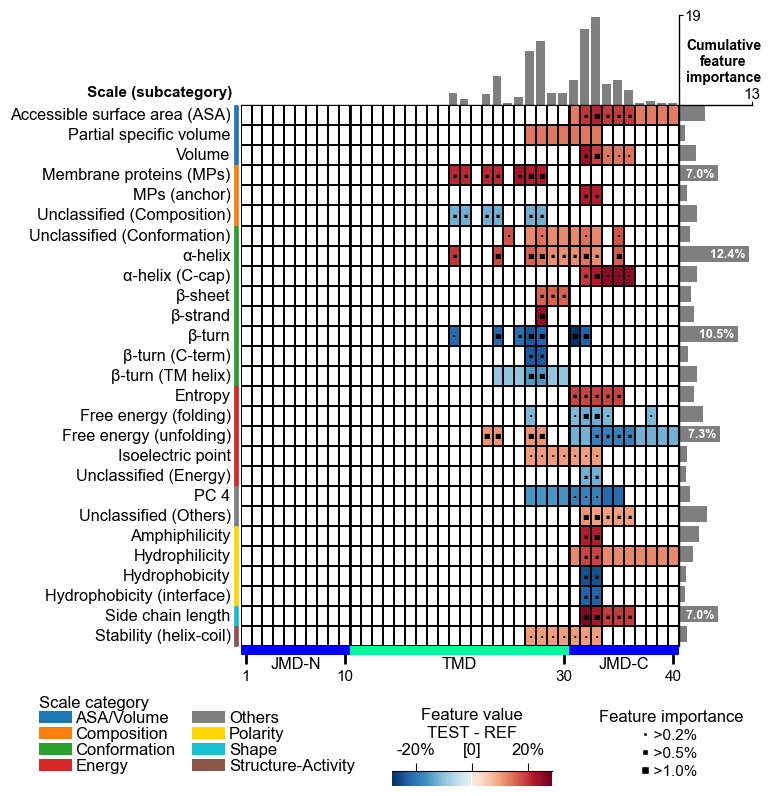

In [4]:
import matplotlib.pyplot as plt

cpp_plot = aa.CPPPlot()                 # feature_map is an INSTANCE method
aa.plot_settings(font_scale=0.65, weight_bold=False)
cpp_plot.feature_map(df_feat=df_feat)
plt.show()

## How to interpret

| Output | Non-expert reading |
| --- | --- |
| high `abs_auc` | strong group-separating property |
| positive `mean_dif` | property is **higher** in the test class in that region |
| negative `mean_dif` | property is **higher** in the reference class |
| a positional feature (e.g. a `TMD-Segment(...)`) | the signal depends on *where* in the part it occurs |
| a hydrophobicity subcategory dominating | one group is more hydrophobic in that region |

Read the feature map as: *rows = physicochemical properties, columns = positions along the parts, colour = direction & strength of the difference.* A robust signature shows coherent blocks, not scattered single cells.

## Common mistakes

- **Calling `CPP(df_seq=...)` or `CPP().run(df_seq, labels)`** - `CPP` takes `df_parts`; build them with `SequenceFeature.get_df_parts` first.
- **Treating `CPPPlot.feature_map` as static** - it is an *instance* method (`aa.CPPPlot().feature_map(...)`), and it needs a `feat_importance` column (add it with `TreeModel.add_feat_importance`).
- **Over-reading a single feature** - interpret the *signature* (blocks of related features), and check stability before drawing biological conclusions (see the *Validate* protocol).
- **Using `len(df_seq)` for class sizes** - use the `label` column; `load_dataset(..., n=N)` returns `2N` rows (N per class).

## Next step

- **Choose your level** - is this a residue, domain, or protein task? See *Protocol 2 - Prediction tasks / levels*.
- **Explain a prediction** - turn the signature into per-sample, single-residue explanations: see *Protocol 3 - Interpretability* (`ShapModel`, sample-level `feature_map`).
- **Trust the result** - repeated-CV, bootstrap CIs and shuffled-label controls: see *Protocol 4 - Validate / Can I trust this?*
- **Reduce redundancy** - see [feature selection & redundancy reduction (#90)](https://github.com/breimanntools/aaanalysis/issues/90).